# Experiment 5 : Sensitivity Analysis

**Drug Modeled:** Gefitinib

**Condition Tested:** Comparing effects of all parameters along the pathway

**Research Question:** Which parameters most strongly influence proliferation?

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Diffusion coefficient array
D_values = np.logspace(-7, -6, 10)

# Number of spatial points
nx = 200

# Tumor depth range
x = np.linspace(0, 0.2, nx) # cm, (0-2 mm)

# Hill coefficient
n = 1

# Literature IC_50 value, concentration of gefitinib to achieve 50% inhibition of EGFR
ic_50 = 0.3

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha_erk = k_act / k_deact

# Proliferation Hill coefficient
m = 4

# Half-maximal ERK activity
K = 0.5

def diffusion_solver(D_base):
    # Tissue depth range (cm)
    L = 0.2             # 2 mm

    dx = x[1] - x[0]

    # Total simulation time (s)
    T = 3600            # 1 hour

    # Number of time steps
    nt = 15000

    dt = T / nt

    # Layer boundaries (cm)
    boundary_1 = 0.05   # 0.5 mm
    boundary_2 = 0.12   # 1.2 mm

    # Tumor density coefficient
    alpha_i = 0.2

    # Diffusion coefficients for each layer (cm^2/s)
    D1 = D_base             # Outer tumor region
    D2 = alpha_i * D_base   # Dense / diffusion-limited region
    D3 = D_base             # Deeper tumor region

    # Spatial diffusitivity profile
    D = np.full(nx, D1)

    D[x >= boundary_1] = D2
    D[x >= boundary_2] = D3

    # Constant drug source at vessel boundary
    C_source = 1.0

    # Saving buffer
    save_every = 25

    # Solving for spatial concentration profile
    C = np.zeros(nx)
    
    C[0] = C_source
    saved_profiles = []

    # Time-stepping loop
    for t in range(nt):
        C_new = C.copy()

        for i in range(1, nx - 1):
            # diffusitivies
            D_left = (D[i] + D[i-1]) / 2
            D_right = (D[i] + D[i+1]) / 2

            # diffusion fluxes
            J_left = -D_left * (C[i] - C[i-1]) / dx
            J_right = -D_right * (C[i+1] - C[i]) / dx

            # update concentration
            C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

        C = C_new

        # Re-apply source boundary condition
        C[0] = C_source

        if (t % save_every) == 0:
            saved_profiles.append(C.copy())
    
    C = np.array(saved_profiles)
    return C

def egfr_activity(C, IC50, n):
    A = 1 / (1 + (C / IC50) ** n)
    return A

def erk_activity(EGFR, alpha):
    ERK = alpha * EGFR
    return ERK

def proliferation(ERK, K, m):
    P = ERK ** m / (ERK ** m + K ** m)
    return P

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Solving average proliferation rates
prolif_avg = []

for D_base in D_values:
    C = diffusion_solver(D_base)
    EGFR = egfr_activity(C, ic_50, n)
    ERK = erk_activity(EGFR, alpha_erk)
    P = proliferation(ERK, K, m)
    prolif_avg.append(np.mean(P[-1, :]))

# See if this can run faster!

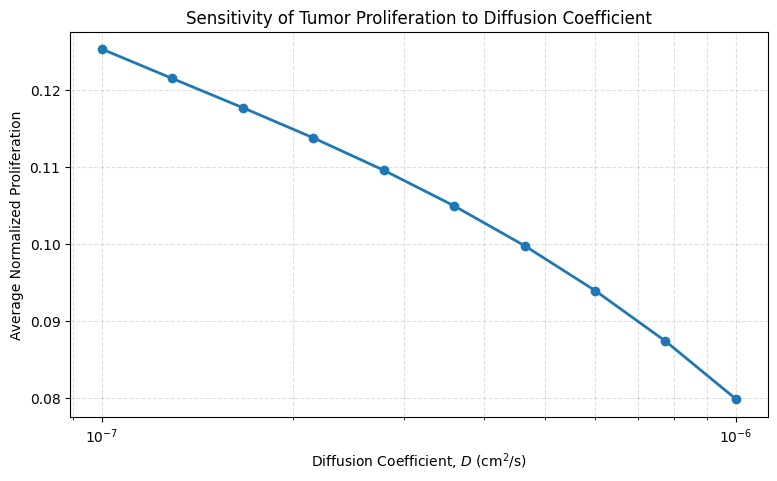

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(D_values, prolif_avg, marker='o', linewidth=2)

plt.xscale('log')

plt.xlabel(r'Diffusion Coefficient, $D$ (cm$^2$/s)')
plt.ylabel('Average Normalized Proliferation')
plt.title('Sensitivity of Tumor Proliferation to Diffusion Coefficient')

plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.show()

## Figure 5A

**Figure 5A.** Sensitivity of predicted average tumor cell proliferation ($P_{avg}$) to the effective diffusion coefficient ($D_{eff}$) of gefitinib. The diffusion coefficient was varied over one order of magnitude while maintaining a constant heterogeneous tissue architecture. The average was computed from the final proliferation field. Increasing diffusion coefficients resulted in progressively lower average proliferation, indicating that improved drug transport enhances therapeutic efficacy by increasing intratumoral drug penetration.

### Observations

As the baseline diffusion coefficient increased, the average normalized proliferation decreased across the simulated tumor. The relationship was monotonic, with larger diffusion coefficients producing progressively greater reductions in proliferation. The negative slope indicates that enhanced molecular transport consistently improves the biological response predicted by the model.

### Interpretation

Increasing the diffusion coefficient allows gefitinib to penetrate more effectively through the heterogeneous tumor tissue, exposing a larger fraction of tumor cells to inhibitory drug concentrations. Consequently, a greater proportion of the EGFR signaling pathway is suppressed, resulting in reduced ERK activity and lower predicted proliferation rates. These findings demonstrate that drug transport properties influence not only spatial concentration profiles but also the overall therapeutic response of the tumor.

### Discussion

The sensitivity analysis identifies drug diffusion as a key determinant of treatment efficacy within the computational framework. Because the heterogeneous tissue architecture was preserved throughout the parameter sweep, the observed changes in proliferation are dependent on the intrinsic transport properties of gefitinib rather than changes in tumor structure. This highlights the importance of molecular diffusion in determining the extent of pathway inhibition achieved throughout the tumor.

From a biomedical perspective, these results suggest that therapeutic strategies which improve effective intratumoral drug transport (modifying molecular physicochemical properties, improving formulation or delivery methods, or reducing extracellular transport barriers) may substantially enhance treatment efficacy. More broadly, the analysis demonstrates the value of sensitivity analysis in systems biology by identifying diffusion as an influential model parameter whose variation propagates through transport, signaling, and proliferation to alter the predicted therapeutic response.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# IC50 array
ic_50_values = np.linspace(0.1, 0.6, 10)

# Diffusison coefficient
D = 5e-7

# Number of spatial points
nx = 200

# Tumor depth range
x = np.linspace(0, 0.2, nx) # cm, (0-2 mm)

# Hill coefficient
n = 1

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha_erk = k_act / k_deact

# Proliferation Hill coefficient
m = 4

# Half-maximal ERK activity
K = 0.5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Solving average proliferation rates
prolif_avg = []

for 